## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import logging
    
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import msml610_utils as ut

ut.config_notebook()

# Set plotting style.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
vim support installed: restart the notebook, if needed


Python 3.12.3
Linux 589569fe8102 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 aarch64 aarch64 GNU/Linux


In [3]:
import arviz as az
import xarray as xr
import pymc as pm
import scipy.stats as stats
import preliz as pz

import L05_02_02_overfitting_utils as utils

# g-h filter

In [4]:
n_samples = 12

# We assume we know the real weight.
ground_truth = 160.0 + np.arange(0, n_samples)

# This is what we measure.
measured_weights = np.array([
    158.0, 164.2, 160.3, 159.9, 162.1, 164.6, 169.6, 167.4, 166.4, 171.0,
    171.2, 172.6
])

## Knowing gain_rate

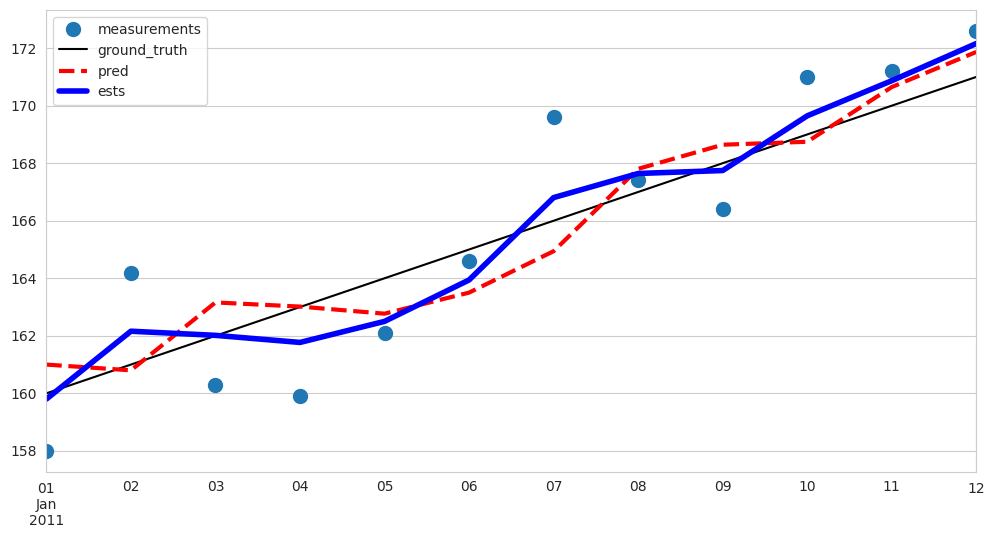

In [6]:
time_step = 1
# This is the blending factor.
weight_scale = 4 / 10.0
# This is the internal model.
gain_rate = 1.0
# This is the initial weight.
weight = 160.0

ests, preds = ut.predict_using_gain_guess(
    weight, measured_weights, gain_rate, weight_scale, time_step)

ut.plot_gh_filter_results(measured_weights, preds, ests, ground_truth)

## Wrong guess of gain_rate

In [ ]:
time_step = 1
weight_scale = 4 / 10.0
gain_rate = -10.0
weight = 160.0

ests, preds = ut.predict_using_gain_guess(
    weight, measured_weights, gain_rate, weight_scale, time_step)

ut.plot_gh_filter_results(measured_weights, preds, ests, ground_truth)

## Learning gain_rate

In [ ]:
time_step = 1
# Gains for update step.
weight_scale = 4 / 10.0
gain_scale = 1 / 3.0
# Initial guess of gain_rate.
gain_rate = -1.0
weight = 160.0

ests, preds = ut.predict_learning_gain_rate(
    weight, measured_weights, gain_rate, weight_scale, gain_scale, time_step)

ut.plot_gh_filter_results(measured_weights, preds, ests, ground_truth)

## Noisy measurements

In [ ]:
vals, ground_truth = ut.gen_linear_noisy_data(x0=0, dx=1, count=100, noise_factor=5)
# TODO(gp): Fix this.
pd.Series(ground_truth).plot();
pd.Series(vals).plot();

In [ ]:
vals, ground_truth = ut.gen_linear_noisy_data(x0=0, dx=1, count=30, noise_factor=1)
ests = ut.gh_filter(data=vals,
                  # Initial guesses (actually correct!).
                  x0=0, dx=1, dt=1,
                  # g, h params.
                  g=0.1, h=0.02)

preds = None
ut.plot_gh_filter_results(vals, preds, ests, ground_truth)

In [ ]:
# Wrong initial guess for state.
vals, ground_truth = ut.gen_linear_noisy_data(x0=0, dx=1, count=100, noise_factor=10)
ests = ut.gh_filter(data=vals,
                  # Initial guesses (wrong!).
                  x0=100, dx=2,
                  dt=1, g=0.2, h=0.02)
preds = None
ut.plot_gh_filter_results(vals, preds, ests, ground_truth)

In [ ]:
# Extreme noise.
vals, ground_truth = ut.gen_linear_noisy_data(x0=0, dx=1, count=100, noise_factor=100)
ests = ut.gh_filter(data=vals, x0=100, dx=1, dt=1, g=0.1, h=0.02)
preds = None
ut.plot_gh_filter_results(vals, preds, ests, ground_truth)

In [ ]:
# Non linear ground truth.
vals, ground_truth = ut.gen_non_linear_noisy_data(x0=0, dx=1, count=100, noise_factor=1000, accel=5)

# TODO(gp): Fix this.
pd.Series(ground_truth).plot();
pd.Series(vals).plot();

In [ ]:
vals, ground_truth = ut.gen_non_linear_noisy_data(x0=0, dx=1, count=20, noise_factor=100, accel=5)
ests = ut.gh_filter(data=vals, x0=100, dx=1, dt=1, g=0.1, h=0.02)

preds = None
ut.plot_gh_filter_results(vals, preds, ests, ground_truth)

## Varying g

In [ ]:
# If g is smaller we follow more our model than the measurements.
# If g is larger we follow more the measurements than our model
# If g is too large we follow the measurements and reject no noise.
np.random.seed(100)
zs, ground_truty = ut.gen_linear_noisy_data(x0=5, dx=5, count=50, noise_factor=50)
df = pd.DataFrame(zs)
df.columns = ["measures"]

df["ground_truth"] = ground_truty
df["g=0.1"] = ut.gh_filter(data=zs, x0=0., dx=5., dt=1., g=0.1, h=0.01)
df["g=0.4"] = ut.gh_filter(data=zs, x0=0., dx=5., dt=1., g=0.4, h=0.01)
df["g=0.8"] = ut.gh_filter(data=zs, x0=0., dx=5., dt=1., g=0.8, h=0.01)

df.drop("measures", axis=1).plot()
df["measures"].plot(marker="o", markersize=10, color="b",
                    # Hide line.
                    linestyle='None');

In [ ]:
# If g is large we follow more the measures than our model.
zs = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
for i in range(50):
    zs.append(14)
df = pd.DataFrame(zs)
df.columns = ["measures"]

df["g=0.1"] = ut.gh_filter(data=zs, x0=0., dx=1, dt=1., g=0.1, h=0.01)
df["g=0.4"] = ut.gh_filter(data=zs, x0=0., dx=1, dt=1., g=0.4, h=0.01)
df["g=0.8"] = ut.gh_filter(data=zs, x0=0., dx=1, dt=1., g=0.8, h=0.01)

df.plot();

## Varying h
- h affects how much we favor the measurement of $\frac{dx}{dt}$ vs our prediction
- If the signal is varying a lot, then we will react to the transient rapidly

In [ ]:
# Go from 0 to 1 in 50 steps (dx = 1 / 50 = 0.02) without noise.
zs = np.linspace(0, 1, 50)
df = pd.DataFrame(zs)
df.columns = ["measures"]

# dx is close to ground truth with small h.
# We track the signal right.
df["dx=0 h=0.05"] = ut.gh_filter(data=zs, x0=0, dx=0, dt=1.0, g=.2, h=0.05)

# dx is wrong, with small h.
# There is big ringing, and we adapt slowly (lower frequency).
df["dx=2 h=0.05"] = ut.gh_filter(data=zs, x0=0, dx=2, dt=1.0, g=.2, h=0.05)

# dx is wrong, with large h.
# Small ringing with higher frequency.
df["dx=2 h=0.5"] = ut.gh_filter(data=zs, x0=0, dx=2, dt=1.0, g=.2, h=0.5)

df.plot();

# Interactice example

In [ ]:
zs1, _ = ut.gen_linear_noisy_data(x0=5, dx=5, count=100, noise_factor=50)

fig = None

def interactive_gh(x, dx, g, h):
    global fig
    if fig is not None:
        plt.close(fig)
    fig = plt.figure()
    data = ut.gh_filter(data=zs1, x0=x, dx=dx, g=g, h=h)
    plt.scatter(list(range(len(zs1))), zs1, marker="+", lw=1)
    plt.plot(data, color='b')
    
interactive_gh(0, 5, 0.1, 0.02)

In [ ]:
from ipywidgets import interact, FloatSlider

interact(interactive_gh,
         x=FloatSlider(value=0., min=-200, max=2000, continuous_update=False),
         dx=FloatSlider(value=5., min=-50., max=50, continuous_update=False),
         g=FloatSlider(value=0.1, min=0.01, max=2, step=.02, continuous_update=False), 
         h=FloatSlider(value=0.02, min=0.0, max=0.5, step=0.01, continuous_update=False));

## Discrete Bayes Filter

In [ ]:
belief = np.array([1.0 / 10] * 10)
print(belief)

In [ ]:
ut.plot_dog_in_office_pdf(belief)

In [ ]:
# The sensor says the dog is in front of a door.
belief = np.array([1/3, 1/3, 0, 0, 0, 0, 0, 0, 1/3, 0])
ut.plot_dog_in_office_pdf(belief)

In [ ]:
# If the sensor reports "door", "move right", "door", we know that the door is at position 0.
belief = np.array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])
ut.plot_dog_in_office_pdf(belief)

In [ ]:
# If sensors are noisy we can't conclude with certainty that we are in front of a door.
# Assume that the sensor is 3x more likely to be right than wrong
# - We need to scale the probability by 3 and then normalize it to sum to 1
belief = np.array([0.188, 0.188, 0.062, 0.062, 0.062, 0.062, 0.062, 0.062, 0.188,
       0.062])
belief /= sum(belief)
ut.plot_dog_in_office_pdf(belief)